In [1]:
import numpy as np
import os, sys
import matplotlib.pyplot as plt
import anndata as ad

# Include src directory in the path dynamically
notebook_dir = os.path.abspath("")
src_path = os.path.join(notebook_dir, "../src")
sys.path.append(src_path)

import preprocessing.lipidomics as lipidomics
import alignment.alignment as alignment
from constants import MsiIntensityNormalization, DecompositionMethod, MsiIonMode

In [2]:
PATH = "/staging/leuven/stg_00077/projects/Lorenzo/FOCUS/Nina/"
SAMPLE_ID = "20250828_NEG"
MODALITY_NAME = "MSI"

OUTPUT_PATH =  os.path.join(PATH, SAMPLE_ID, 'preprocessing', MODALITY_NAME)

In [3]:
msi_sample = lipidomics.MsiSample(
    source_path = PATH,
    sample_id=SAMPLE_ID,
    modality_name=MODALITY_NAME,
    double_ion_mode=False,
    ion_mode=MsiIonMode.POSITIVE,
)

In [ ]:
from sklearn.decomposition import PCA, NMF

def visualize(intensities: np.ndarray, raster_coords: np.ndarray):

	# Compute the PCA of the intensities
	pca = PCA(n_components=3)
	pca_result = pca.fit_transform(intensities)

	# Normalize each component of the PCA independently to [0, 255]
	pca_normalized = np.zeros_like(pca_result, dtype=np.uint8)
	for i in range(3):
		component = pca_result[:, i]
		component_min = component.min()
		component_max = component.max()
		if component_max - component_min > 0:
			pca_normalized[:, i] = ((component - component_min) / (component_max - component_min) * 255).astype(np.uint8)
		else:
			pca_normalized[:, i] = np.zeros_like(component, dtype=np.uint8)

	img = np.zeros((raster_coords[:,:,1].max()+1, raster_coords[:,:,0].max()+1, 3), dtype=np.uint8)
	for index, ((x1, y1), (x2, y2)) in enumerate(raster_coords):
		img[y1:y2, x1:x2] = pca_normalized[index]

	# Add 30 pixel padding around the image
	pad_width = 30
	img = np.pad(img, ((pad_width, pad_width), (pad_width, pad_width), (0, 0)), mode='constant', constant_values=0)

	# Display the image
	plt.figure(figsize=(15,15))
	plt.imshow(img, cmap='gray')
	plt.title("Rasterized image")
	plt.show()


In [5]:
msi_dataset = lipidomics.MsiDataset([msi_sample])

In [13]:
msi_dataset.process_dataset(intensity_normalization=MsiIntensityNormalization.TIC)

Aligning intensities to reference M/Z: 100%|██████████| 1/1 [02:20<00:00, 140.25s/sample]


In [15]:
# Load the processed data
adata = ad.read_h5ad(os.path.join(OUTPUT_PATH, f"{SAMPLE_ID}_{MODALITY_NAME}_processed.h5ad"))

Explained variance ratio of the first 3 components: [0.4815022  0.2448822  0.09683428]
PCA result shape: (121836, 3)
Raster coords shape: (121836, 3)
Image shape before padding: (9681, 10921, 3)


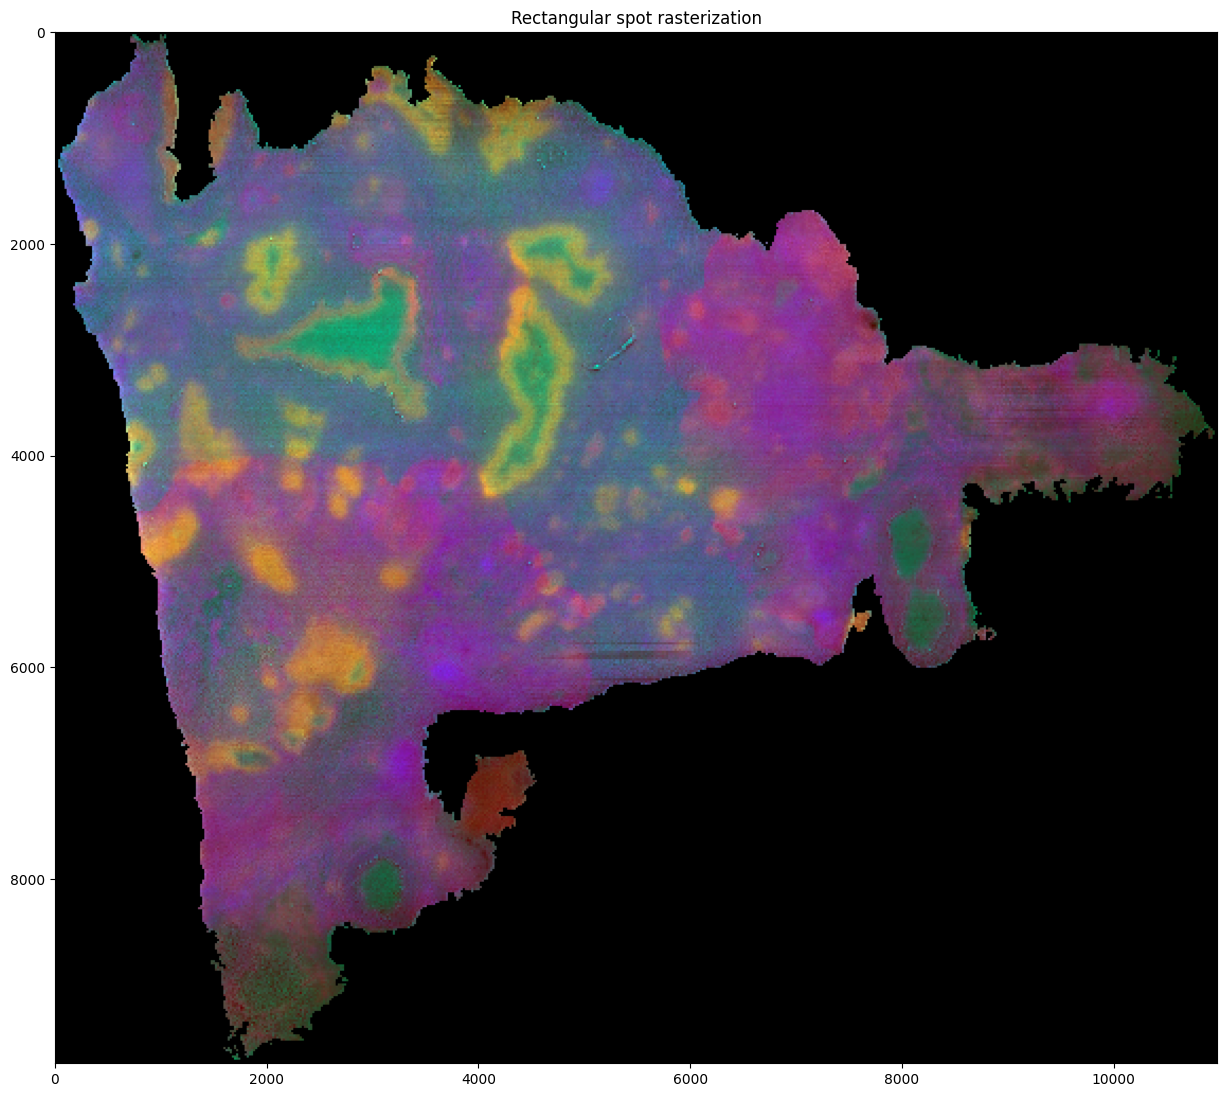

In [16]:
visualize(adata.X, adata.obsm['raster_coordinates'])

In [19]:
# Compute PCA with 3 components
pca = PCA(n_components=3)
pca_result = pca.fit_transform(adata.X)

# Normalize the result to [0, 1]
pca_result = (pca_result - pca_result.min()) / (pca_result.max() - pca_result.min())

/tmp/ipykernel_1442912/303681753.py:6: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(embedding[:,0], embedding[:,1], c=pca_result, s=5, cmap='viridis')


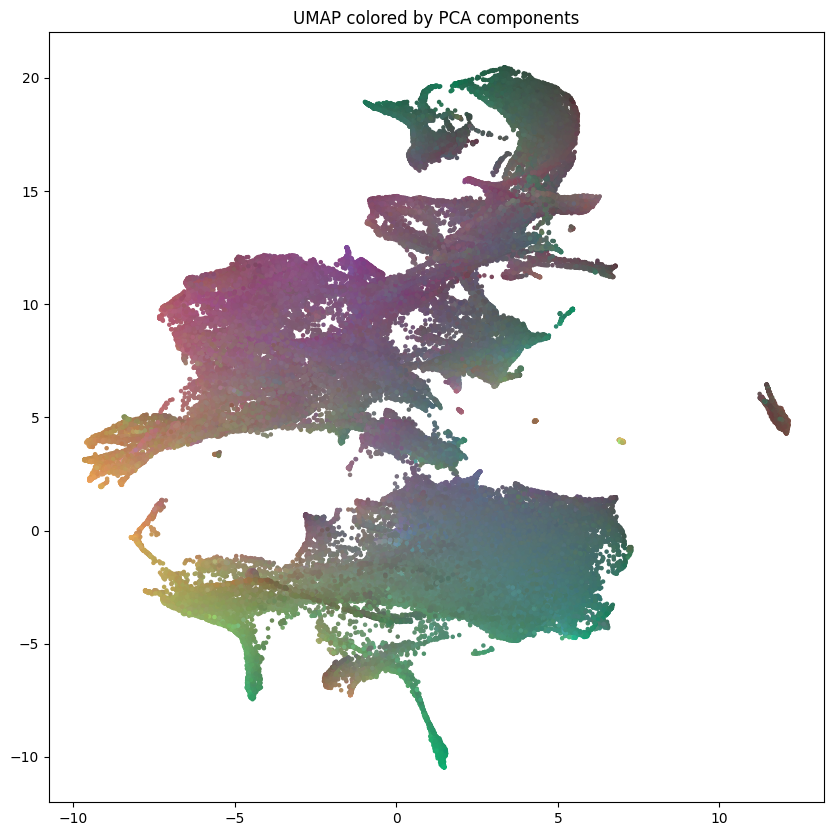

In [20]:
# Compute UMAP and use the PCA result as color
import umap
reducer = umap.UMAP(n_components=2)
embedding = reducer.fit_transform(adata.X)
plt.figure(figsize=(10,10))
plt.scatter(embedding[:,0], embedding[:,1], c=pca_result, s=5, cmap='viridis')
plt.title("UMAP colored by PCA components")
plt.show()